In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.common.utils import get_root_directory
from src.visualisation.plotter import Plotter
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import calendar
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
import gensim
from gensim.utils import simple_preprocess
import numpy as np

## Data Loading

In [2]:
root_dir = get_root_directory()

## ETH

In [109]:
eth_etherscan = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_etherscan.csv")
eth_ol = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_oklink.csv")

In [88]:
eth_etherscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        2467 non-null   object 
 1   Open                        2467 non-null   float64
 2   High                        2467 non-null   float64
 3   Low                         2467 non-null   float64
 4   Close                       2467 non-null   float64
 5   Adj Close                   2467 non-null   float64
 6   Volume                      2467 non-null   int64  
 7   AddressCount                2467 non-null   int64  
 8   AverageDailyTransactionFee  2467 non-null   float64
 9   AvgGasPrice                 2467 non-null   int64  
 10  BlockCountRewards           2467 non-null   int64  
 11  BlockDifficulty             2467 non-null   float64
 12  BlockReward                 2467 non-null   float64
 13  BlockSize                   2467 

In [89]:
eth_etherscan.drop(columns=["Adj Close", "AddressCount", "BlockReward", "Ethersupply2", "BlockDifficulty", "NetworkHash", "TxGrowth", "Uncles", "TransactionFee"], inplace=True)

In [90]:
eth_etherscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        2467 non-null   object 
 1   Open                        2467 non-null   float64
 2   High                        2467 non-null   float64
 3   Low                         2467 non-null   float64
 4   Close                       2467 non-null   float64
 5   Volume                      2467 non-null   int64  
 6   AverageDailyTransactionFee  2467 non-null   float64
 7   AvgGasPrice                 2467 non-null   int64  
 8   BlockCountRewards           2467 non-null   int64  
 9   BlockSize                   2467 non-null   int64  
 10  BlockTime                   2467 non-null   float64
 11  DailyActiveEthAddress       2467 non-null   int64  
 12  deployed contracts          2467 non-null   int64  
 13  GasLimit                    2467 

In [91]:
columns={'Open': 'YF_Op', 'High': 'YF_Hi', 'Low': 'YF_Lo', 'Close':'YF_Cls', 'Volume':'YF_Vol', 'AverageDailyTransactionFee':'ES_AvgTransFee','AvgGasPrice':'ES_AvgGasPrc',
        'BlockCountRewards': 'ES_BlkCnt', 'BlockSize':'ES_BlkSz', 'BlockTime':'ES_BlkTm', 'DailyActiveEthAddress':'ES_ActAdd','deployed contracts':'ES_DepCon','GasLimit':'ES_GasLmt',
        'GasUsed': 'ES_GasUsd', 'verified contracts':"ES_VerCon"}
eth_etherscan.rename(columns=columns, inplace=True)

In [92]:
eth_etherscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2467 non-null   object 
 1   YF_Op           2467 non-null   float64
 2   YF_Hi           2467 non-null   float64
 3   YF_Lo           2467 non-null   float64
 4   YF_Cls          2467 non-null   float64
 5   YF_Vol          2467 non-null   int64  
 6   ES_AvgTransFee  2467 non-null   float64
 7   ES_AvgGasPrc    2467 non-null   int64  
 8   ES_BlkCnt       2467 non-null   int64  
 9   ES_BlkSz        2467 non-null   int64  
 10  ES_BlkTm        2467 non-null   float64
 11  ES_ActAdd       2467 non-null   int64  
 12  ES_DepCon       2467 non-null   int64  
 13  ES_GasLmt       2467 non-null   int64  
 14  ES_GasUsd       2467 non-null   int64  
 15  ES_VerCon       2467 non-null   int64  
dtypes: float64(6), int64(9), object(1)
memory usage: 308.5+ KB


In [93]:
eth_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 21 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   ETH Gas price                                      2467 non-null   float64
 8   ETH total supply                                   2447 non-null   float64
 9   ETH dail

In [94]:
list(eth_ol.columns)

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'ETH Gas price',
 'ETH total supply',
 'ETH daily transaction fee',
 'Gas utilization rate of ETH',
 'ETH daily new contracts',
 'ETH market cap',
 'ETH average daily block size',
 'ETH average computing power of the entire network',
 'ETH average daily transaction fee',
 'ETH mining difficulty',
 'ETH number of daily active addresses',
 'Number of new addresses added per day on ETH',
 'ETH number of daily transactions on the chain',
 'ETH daily transaction volume on the chain']

In [95]:
eth_ol.drop(columns= ['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'ETH Gas price',
 'ETH total supply',
 'ETH daily transaction fee',
 'Gas utilization rate of ETH',
 'ETH daily new contracts',
 'ETH average daily block size',
 'ETH average computing power of the entire network',
 'ETH average daily transaction fee',
 'ETH mining difficulty',
 'ETH number of daily active addresses'], inplace=True)

In [96]:
eth_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Date                                           2467 non-null   object 
 1   ETH market cap                                 2467 non-null   float64
 2   Number of new addresses added per day on ETH   2467 non-null   float64
 3   ETH number of daily transactions on the chain  2467 non-null   int64  
 4   ETH daily transaction volume on the chain      2467 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 96.5+ KB


In [97]:
columns = {'ETH market cap': 'OL_MktCap',"Number of new addresses added per day on ETH":"OL_NewAdd", "ETH number of daily transactions on the chain":"OL_ChnTrans", "ETH daily transaction volume on the chain":"OL_ChnVol"}

In [98]:
eth_ol.rename(columns=columns, inplace=True)

In [99]:
eth_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2467 non-null   object 
 1   OL_MktCap    2467 non-null   float64
 2   OL_NewAdd    2467 non-null   float64
 3   OL_ChnTrans  2467 non-null   int64  
 4   OL_ChnVol    2467 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 96.5+ KB


In [100]:
eth = pd.merge(eth_etherscan, eth_ol, on="Date")

In [101]:
eth['Date'] = pd.to_datetime(eth['Date'])
eth = eth.set_index('Date')

In [113]:
eth.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2017-11-09 to 2024-08-10
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YF_Op           2467 non-null   float64
 1   YF_Hi           2467 non-null   float64
 2   YF_Lo           2467 non-null   float64
 3   YF_Cls          2467 non-null   float64
 4   YF_Vol          2467 non-null   int64  
 5   ES_AvgTransFee  2467 non-null   float64
 6   ES_AvgGasPrc    2467 non-null   int64  
 7   ES_BlkCnt       2467 non-null   int64  
 8   ES_BlkSz        2467 non-null   int64  
 9   ES_BlkTm        2467 non-null   float64
 10  ES_ActAdd       2467 non-null   int64  
 11  ES_DepCon       2467 non-null   int64  
 12  ES_GasLmt       2467 non-null   int64  
 13  ES_GasUsd       2467 non-null   int64  
 14  ES_VerCon       2467 non-null   int64  
 15  OL_MktCap       2467 non-null   float64
 16  OL_NewAdd       2467 non-null   float64
 17  OL_ChnTrans    

## BTC

In [103]:
btc_bic = pd.read_csv(f"{root_dir}\data\processed\BTC_data\BTC_bitinfocharts.csv")
btc_ol = pd.read_csv(f"{root_dir}\data\processed\BTC_data\BTC_oklink.csv")

In [105]:
btc_bic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2465 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


In [107]:
btc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 19 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   BTC total supply                                   2467 non-null   float64
 8   BTC market cap                                     2467 non-null   float64
 9   BTC aver

In [108]:
list(btc_ol.columns)

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'BTC total supply',
 'BTC market cap',
 'BTC average daily block size',
 'BTC average computing power of the entire network',
 'BTC average daily transaction fee',
 'BTC mining difficulty',
 'BTC number of daily active addresses',
 'Number of new addresses added per day on BTC',
 'BTC total addresses',
 'BTC number of daily transactions on the chain',
 'BTC full node data size',
 'BTC daily transaction volume on the chain']

In [111]:
btc_ol.drop(columns=[
 'Adj Close',
 'BTC total supply',
 'BTC average computing power of the entire network',
 'BTC total addresses',
 'BTC full node data size'], inplace=True)

In [112]:
btc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 14 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Date                                           2467 non-null   object 
 1   Open                                           2467 non-null   float64
 2   High                                           2467 non-null   float64
 3   Low                                            2467 non-null   float64
 4   Close                                          2467 non-null   float64
 5   Volume                                         2467 non-null   int64  
 6   BTC market cap                                 2467 non-null   float64
 7   BTC average daily block size                   2467 non-null   float64
 8   BTC average daily transaction fee              2467 non-null   float64
 9   BTC mining difficulty                          2467 

In [122]:
columns={'Open': 'YF_Op', 'High': 'YF_Hi', 'Low': 'YF_Lo', 'Close':'YF_Cls', 'Volume':'YF_Vol', 'BTC average daily transaction fee':'OL_AvgTransFee',
         'BTC mining difficulty': 'OL_MinDif', 'BTC average daily block size':'OL_BlkSz', 'BlockTime':'ES_BlkTm', 'BTC number of daily active addresses':'OL_ActAdd','BTC market cap': 'OL_MktCap',"Number of new addresses added per day on BTC":"OL_NewAdd", "BTC number of daily transactions on the chain":"OL_ChnTrans", "BTC daily transaction volume on the chain":"OL_ChnVol"}
btc_ol.rename(columns=columns, inplace=True)

In [124]:
btc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2467 non-null   object 
 1   YF_Op           2467 non-null   float64
 2   YF_Hi           2467 non-null   float64
 3   YF_Lo           2467 non-null   float64
 4   YF_Cls          2467 non-null   float64
 5   YF_Vol          2467 non-null   int64  
 6   OL_MktCap       2467 non-null   float64
 7   OL_BlkSz        2467 non-null   float64
 8   OL_AvgTransFee  2467 non-null   float64
 9   OL_MinDif       2467 non-null   float64
 10  OL_ActAdd       2466 non-null   float64
 11  OL_NewAdd       2467 non-null   int64  
 12  OL_ChnTrans     2467 non-null   int64  
 13  OL_ChnVol       2467 non-null   float64
dtypes: float64(10), int64(3), object(1)
memory usage: 270.0+ KB


In [118]:
list(btc_bic.columns)

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Transactions',
 'Block Size',
 'Difficulty',
 'Hashrate',
 'Active Addressses']

In [120]:
btc_bic.drop(columns=['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Transactions',
 'Block Size',
 'Difficulty',
 'Active Addressses'], inplace=True)


In [125]:
btc_bic.rename(columns={"Hashrate":"BIC_HshRt"}, inplace=True)

NameError: name 'bit_bic' is not defined

In [126]:
btc_bic

,Date,BIC_HshRt
0,2017-11-09,1.044304e+19
1,2017-11-10,1.010747e+19
2,2017-11-11,6.857211e+18
3,2017-11-12,4.877691e+18
4,2017-11-13,7.975361e+18
...,...,...
2462,2024-08-06,6.502267e+20
2463,2024-08-07,5.634361e+20
2464,2024-08-08,5.918414e+20
2465,2024-08-09,5.890192e+20


In [139]:
btc = pd.merge(btc_ol, btc_bic, on="Date")

In [140]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2467 non-null   object 
 1   YF_Op           2467 non-null   float64
 2   YF_Hi           2467 non-null   float64
 3   YF_Lo           2467 non-null   float64
 4   YF_Cls          2467 non-null   float64
 5   YF_Vol          2467 non-null   int64  
 6   OL_MktCap       2467 non-null   float64
 7   OL_BlkSz        2467 non-null   float64
 8   OL_AvgTransFee  2467 non-null   float64
 9   OL_MinDif       2467 non-null   float64
 10  OL_ActAdd       2466 non-null   float64
 11  OL_NewAdd       2467 non-null   int64  
 12  OL_ChnTrans     2467 non-null   int64  
 13  OL_ChnVol       2467 non-null   float64
 14  BIC_HshRt       2467 non-null   float64
dtypes: float64(11), int64(3), object(1)
memory usage: 289.2+ KB


In [141]:
btc['Date'] = pd.to_datetime(btc['Date'])
btc = btc.set_index('Date')

In [142]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2017-11-09 to 2024-08-10
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YF_Op           2467 non-null   float64
 1   YF_Hi           2467 non-null   float64
 2   YF_Lo           2467 non-null   float64
 3   YF_Cls          2467 non-null   float64
 4   YF_Vol          2467 non-null   int64  
 5   OL_MktCap       2467 non-null   float64
 6   OL_BlkSz        2467 non-null   float64
 7   OL_AvgTransFee  2467 non-null   float64
 8   OL_MinDif       2467 non-null   float64
 9   OL_ActAdd       2466 non-null   float64
 10  OL_NewAdd       2467 non-null   int64  
 11  OL_ChnTrans     2467 non-null   int64  
 12  OL_ChnVol       2467 non-null   float64
 13  BIC_HshRt       2467 non-null   float64
dtypes: float64(11), int64(3)
memory usage: 289.1 KB


In [161]:
btc_com = btc.interpolate(method="time")

In [162]:
btc_com.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2017-11-09 to 2024-08-10
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YF_Op           2467 non-null   float64
 1   YF_Hi           2467 non-null   float64
 2   YF_Lo           2467 non-null   float64
 3   YF_Cls          2467 non-null   float64
 4   YF_Vol          2467 non-null   int64  
 5   OL_MktCap       2467 non-null   float64
 6   OL_BlkSz        2467 non-null   float64
 7   OL_AvgTransFee  2467 non-null   float64
 8   OL_MinDif       2467 non-null   float64
 9   OL_ActAdd       2467 non-null   float64
 10  OL_NewAdd       2467 non-null   int64  
 11  OL_ChnTrans     2467 non-null   int64  
 12  OL_ChnVol       2467 non-null   float64
 13  BIC_HshRt       2467 non-null   float64
dtypes: float64(11), int64(3)
memory usage: 289.1 KB


## LTC

In [168]:
ltc_bic = pd.read_csv(f"{root_dir}\data\processed\LTC_data\LTC_bitinfocharts.csv")
ltc_ol = pd.read_csv(f"{root_dir}\data\processed\LTC_data\LTC_oklink.csv")

In [169]:
ltc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 18 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   LTC total supply                                   2466 non-null   float64
 8   LTC market cap                                     2460 non-null   float64
 9   LTC aver

In [170]:
list(ltc_ol.columns)

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'LTC total supply',
 'LTC market cap',
 'LTC average daily block size',
 'LTC average computing power of the entire network',
 'LTC average daily transaction fee',
 'LTC mining difficulty',
 'LTC number of daily active addresses',
 'Number of new addresses added per day on LTC',
 'LTC total addresses',
 'LTC number of daily transactions on the chain',
 'LTC full node data size']

In [171]:
ltc_ol.drop(columns=[
 'Adj Close',
 'LTC total supply',
 'LTC average computing power of the entire network',
 'LTC total addresses',
 'LTC full node data size'], inplace=True)

In [172]:
ltc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Date                                           2467 non-null   object 
 1   Open                                           2467 non-null   float64
 2   High                                           2467 non-null   float64
 3   Low                                            2467 non-null   float64
 4   Close                                          2467 non-null   float64
 5   Volume                                         2467 non-null   int64  
 6   LTC market cap                                 2460 non-null   float64
 7   LTC average daily block size                   2331 non-null   float64
 8   LTC average daily transaction fee              2330 non-null   float64
 9   LTC mining difficulty                          2330 

In [173]:
columns={'Open': 'YF_Op', 'High': 'YF_Hi', 'Low': 'YF_Lo', 'Close':'YF_Cls', 'Volume':'YF_Vol', 'LTC average daily transaction fee':'OL_AvgTransFee',
         'LTC mining difficulty': 'OL_MinDif', 'LTC average daily block size':'OL_BlkSz', 'LTC number of daily active addresses':'OL_ActAdd','LTC market cap': 'OL_MktCap',"Number of new addresses added per day on LTC":"OL_NewAdd", "LTC number of daily transactions on the chain":"OL_ChnTrans", "LTC daily transaction volume on the chain":"OL_ChnVol"}
ltc_ol.rename(columns=columns, inplace=True)

In [175]:
ltc_ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2467 non-null   object 
 1   YF_Op           2467 non-null   float64
 2   YF_Hi           2467 non-null   float64
 3   YF_Lo           2467 non-null   float64
 4   YF_Cls          2467 non-null   float64
 5   YF_Vol          2467 non-null   int64  
 6   OL_MktCap       2460 non-null   float64
 7   OL_BlkSz        2331 non-null   float64
 8   OL_AvgTransFee  2330 non-null   float64
 9   OL_MinDif       2330 non-null   float64
 10  OL_ActAdd       2466 non-null   float64
 11  OL_NewAdd       2330 non-null   float64
 12  OL_ChnTrans     2330 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 250.7+ KB


In [166]:
# ltc_ol['Date'] = pd.to_datetime(ltc_ol['Date'])
# ltc_ol = ltc_ol.set_index('Date')
# com = ltc_ol.interpolate(method="akima")

In [167]:
# com.info()

In [163]:
# plotter = Plotter(root_dir)
# plotter.plot_lineplot(df=com, x="Date", y="LTC market cap")

In [148]:
ltc_bic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2422 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


In [176]:
list(ltc_bic.columns)

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Transactions',
 'Block Size',
 'Difficulty',
 'Hashrate',
 'Active Addressses']

In [177]:
ltc_bic.drop(columns=['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Transactions',
 'Block Size',
 'Difficulty',
 'Active Addressses'], inplace=True)


In [178]:
ltc_bic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      2467 non-null   object 
 1   Hashrate  2467 non-null   float64
dtypes: float64(1), object(1)
memory usage: 38.7+ KB


In [179]:
ltc_bic.rename(columns={"Hashrate":"BIC_HshRt"}, inplace=True)

In [181]:
ltc = pd.merge(ltc_ol, ltc_bic, on="Date")

In [183]:
ltc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2467 non-null   object 
 1   YF_Op           2467 non-null   float64
 2   YF_Hi           2467 non-null   float64
 3   YF_Lo           2467 non-null   float64
 4   YF_Cls          2467 non-null   float64
 5   YF_Vol          2467 non-null   int64  
 6   OL_MktCap       2460 non-null   float64
 7   OL_BlkSz        2331 non-null   float64
 8   OL_AvgTransFee  2330 non-null   float64
 9   OL_MinDif       2330 non-null   float64
 10  OL_ActAdd       2466 non-null   float64
 11  OL_NewAdd       2330 non-null   float64
 12  OL_ChnTrans     2330 non-null   float64
 13  BIC_HshRt       2467 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 270.0+ KB


In [185]:
ltc["Date"] = pd.to_datetime(ltc["Date"])

In [190]:
ltc = ltc.set_index("Date")

In [191]:
ltc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2017-11-09 to 2024-08-10
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YF_Op           2467 non-null   float64
 1   YF_Hi           2467 non-null   float64
 2   YF_Lo           2467 non-null   float64
 3   YF_Cls          2467 non-null   float64
 4   YF_Vol          2467 non-null   int64  
 5   OL_MktCap       2460 non-null   float64
 6   OL_BlkSz        2331 non-null   float64
 7   OL_AvgTransFee  2330 non-null   float64
 8   OL_MinDif       2330 non-null   float64
 9   OL_ActAdd       2466 non-null   float64
 10  OL_NewAdd       2330 non-null   float64
 11  OL_ChnTrans     2330 non-null   float64
 12  BIC_HshRt       2467 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 269.8 KB


In [192]:
ltc.interpolate(method="time", inplace=True)

In [193]:
ltc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2017-11-09 to 2024-08-10
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YF_Op           2467 non-null   float64
 1   YF_Hi           2467 non-null   float64
 2   YF_Lo           2467 non-null   float64
 3   YF_Cls          2467 non-null   float64
 4   YF_Vol          2467 non-null   int64  
 5   OL_MktCap       2467 non-null   float64
 6   OL_BlkSz        2467 non-null   float64
 7   OL_AvgTransFee  2467 non-null   float64
 8   OL_MinDif       2467 non-null   float64
 9   OL_ActAdd       2467 non-null   float64
 10  OL_NewAdd       2467 non-null   float64
 11  OL_ChnTrans     2467 non-null   float64
 12  BIC_HshRt       2467 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 269.8 KB


## All Data

In [194]:
eth["D_AvgPrc"] = (eth["YF_Op"]+eth["YF_Hi"]+eth["YF_Lo"]+eth["YF_Cls"])/4

In [196]:
btc["D_AvgPrc"] = (btc["YF_Op"]+btc["YF_Hi"]+btc["YF_Lo"]+btc["YF_Cls"])/4

In [197]:
ltc["D_AvgPrc"] = (ltc["YF_Op"]+ltc["YF_Hi"]+ltc["YF_Lo"]+ltc["YF_Cls"])/4

In [204]:
eth.columns = [f"ETH_{column}" for column in eth.columns]

In [206]:
btc.columns = [f"BTC_{column}" for column in btc.columns]

In [207]:
ltc.columns = [f"LTC_{column}" for column in ltc.columns]

In [208]:
all_data = pd.concat([eth, btc, ltc], axis=1)

In [219]:
remo = [col for col in all_data.columns if ("YF" in col) or ("Mkt" in col)]

In [221]:
corr = all_data.drop(columns=remo)

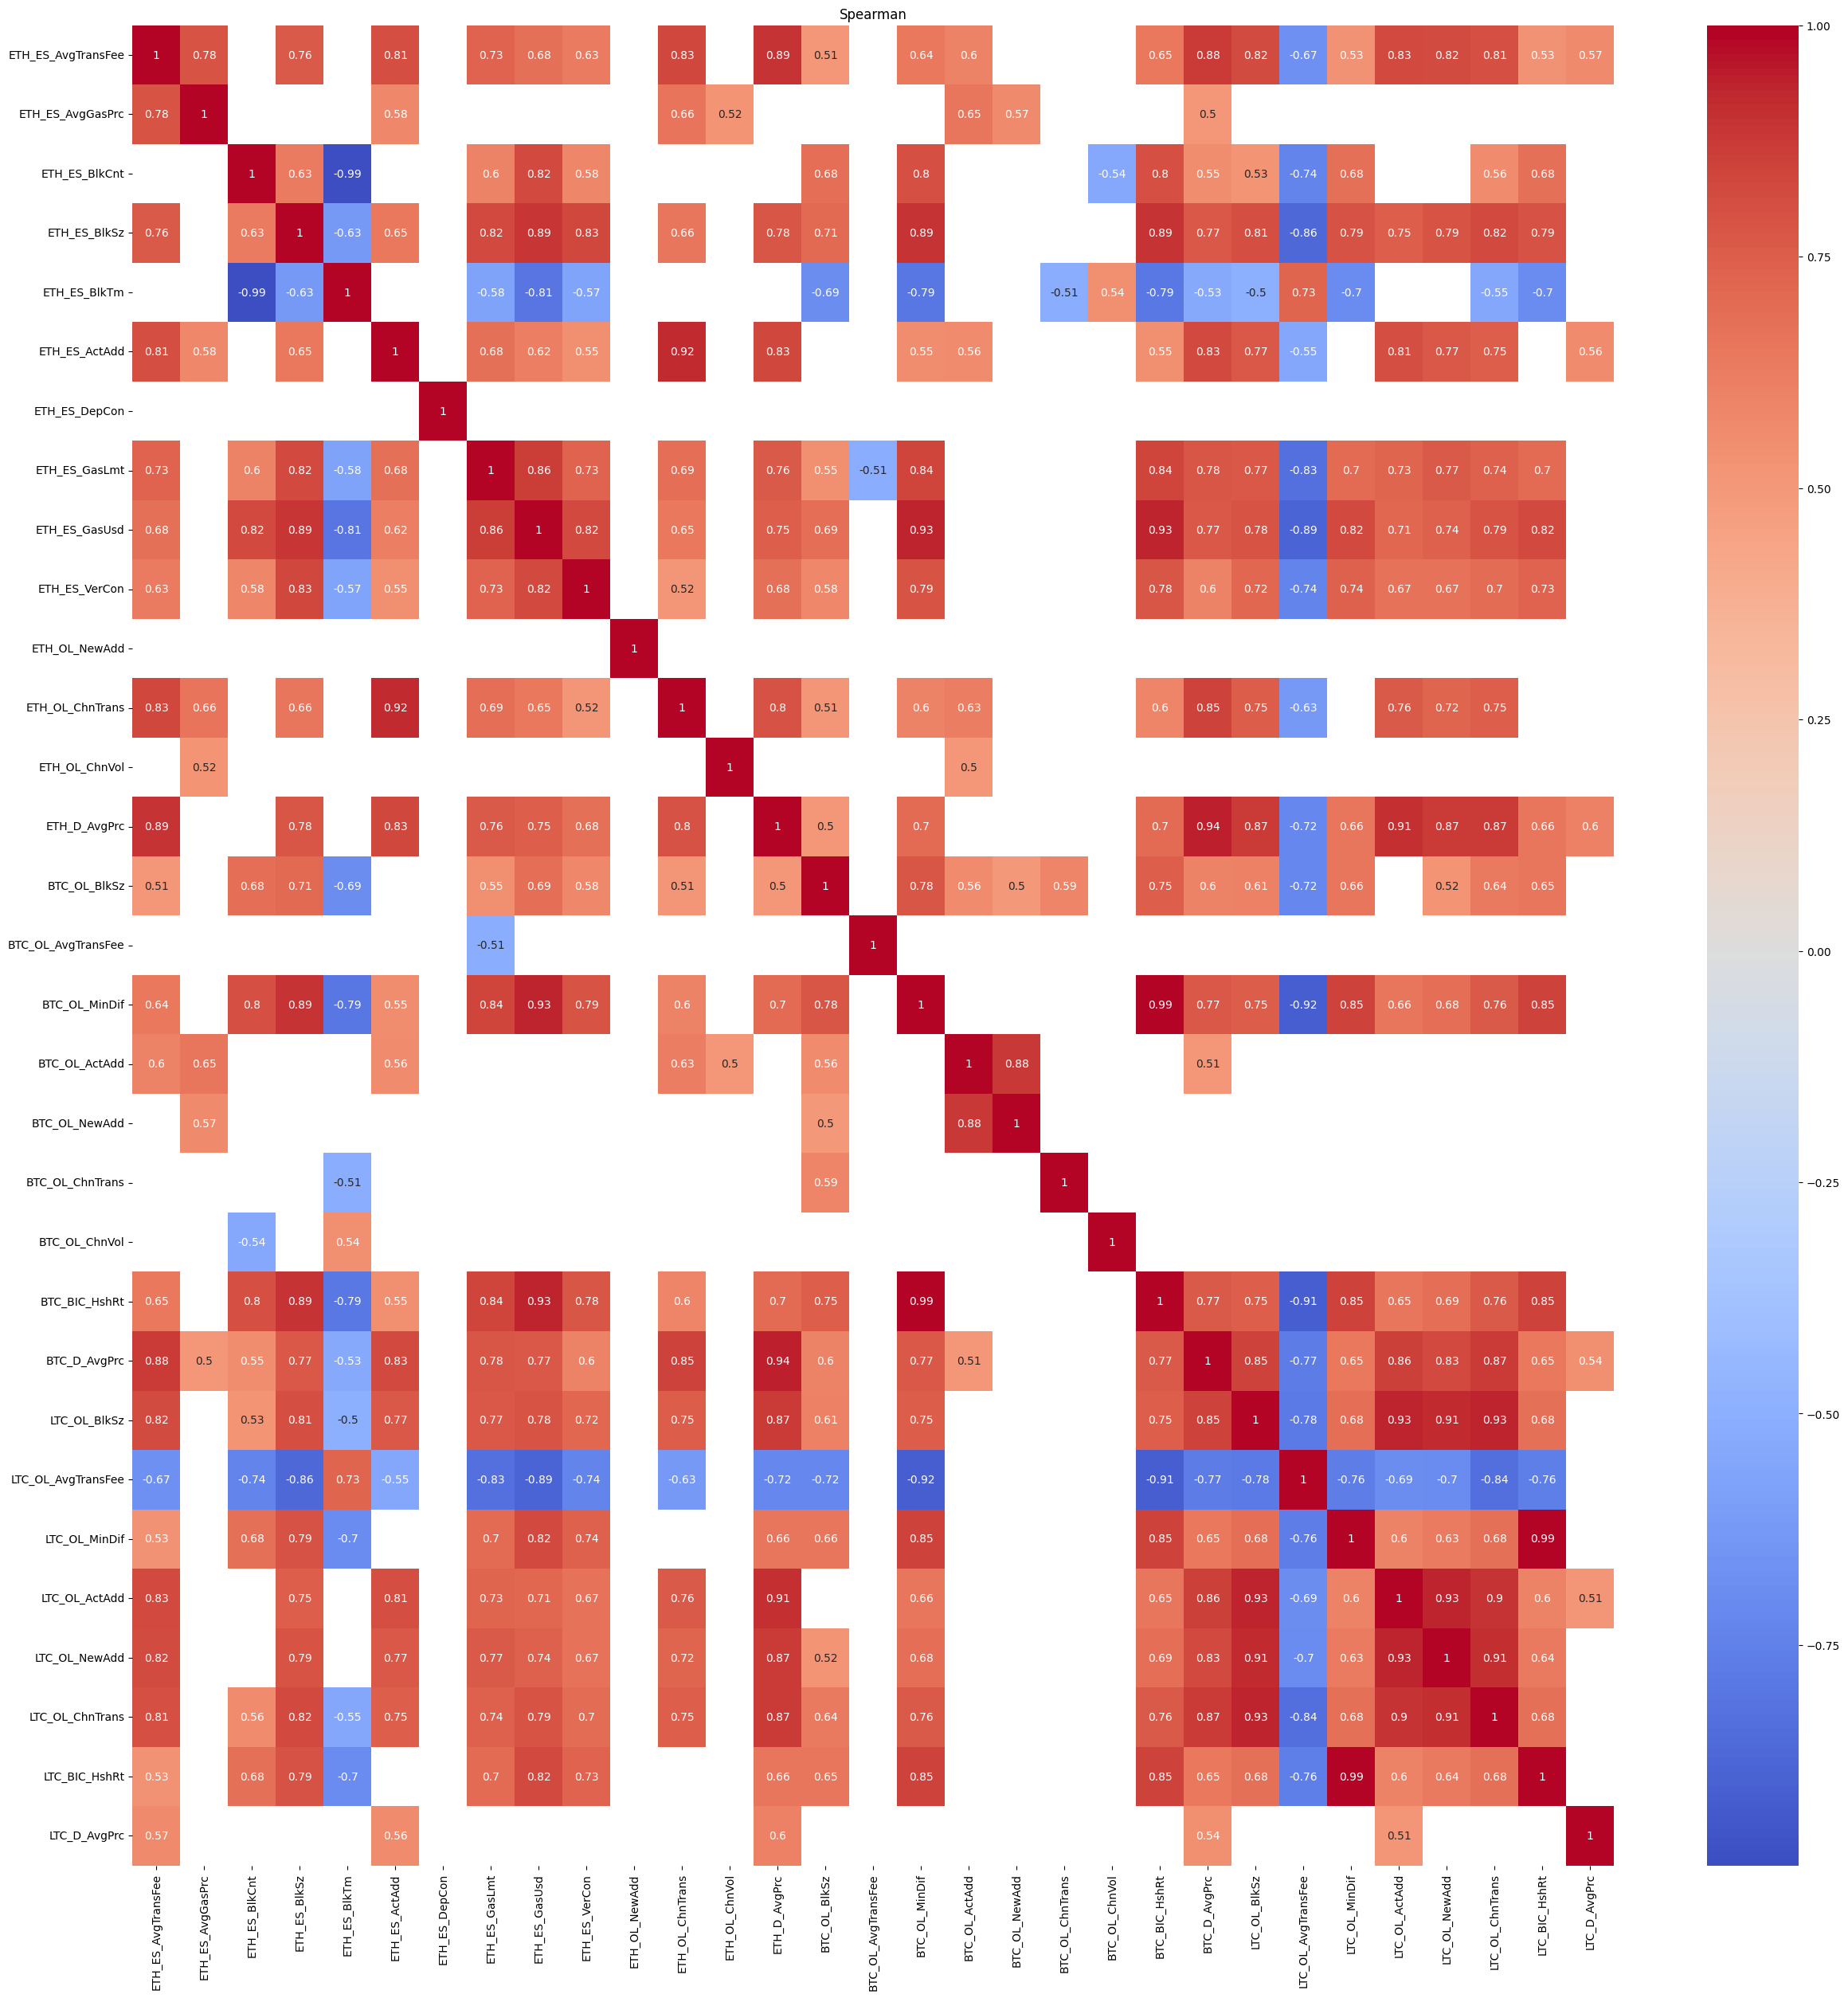

In [231]:
plotter.plot_correlation_matrix(corr, method="spearman", figsize=(30,30), title="Spearman", mask=True, threshold=0.5)

In [230]:
plotter.save_graph()

## Google News

In [3]:
root_dir = get_root_directory()
processed_gn = pd.read_csv(f"{root_dir}\data\processed\Google_News_Headlines_data\google_news_headlines_data.csv")

In [3]:
processed_gn = processed_gn.astype('string')
processed_gn['Date'] = pd.to_datetime(processed_gn['Date'])

In [4]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words("english"))

def generate_clean_tokens(text):
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\b\w{21,}\b', '', text)
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [235]:
processed_gn['cleaned'] = processed_gn['News Headline'].apply(lambda x: generate_clean_tokens(x))

In [4]:
from src.sentiment_analyser.vader_sentiment_analyser import VaderSentimentAnalyser
from src.sentiment_analyser.finbert_sentiment_analyser import FinbertSentimentAnalyser
# VSA = VaderSentimentAnalyser(processed_gn)
# processed_gn = VSA.analyse_sentiment("News Headline")


In [6]:
plotter = Plotter(root_dir)

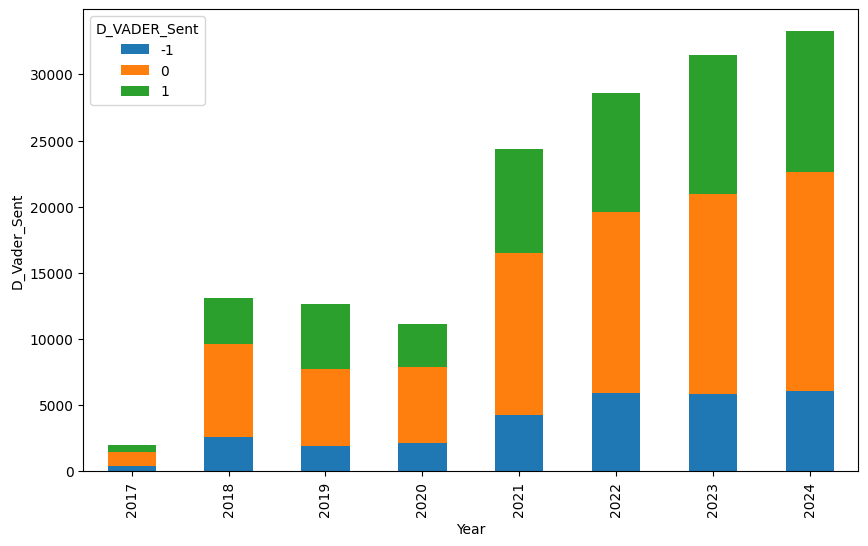

In [7]:
processed_gn['year'] = processed_gn['Date'].dt.year
processed_gn['month'] =processed_gn['Date'].dt.month
grouped = processed_gn.groupby(['year', 'D_VADER_Sent']).size().unstack()
grouped
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent", stacked=True)

In [18]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           156574 non-null  datetime64[ns]
 1   News Headline  156574 non-null  string        
 2   Publisher      156574 non-null  string        
 3   D_VADER_score  156574 non-null  float64       
 4   D_VADER_sent   156574 non-null  object        
 5   year           156574 non-null  int32         
 6   month          156574 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(1), string(2)
memory usage: 7.2+ MB


In [8]:
agg = processed_gn.pivot_table(values="D_VADER_Score", index=["Date", "year"], aggfunc="mean")

In [9]:
agg

,,D_VADER_Score
Date,year,
2017-11-09,2017,0.082633
2017-11-10,2017,0.189088
2017-11-11,2017,0.065342
2017-11-12,2017,0.037093
2017-11-13,2017,0.036083
...,...,...
2024-08-07,2024,0.051544
2024-08-08,2024,0.042091
2024-08-09,2024,0.039904


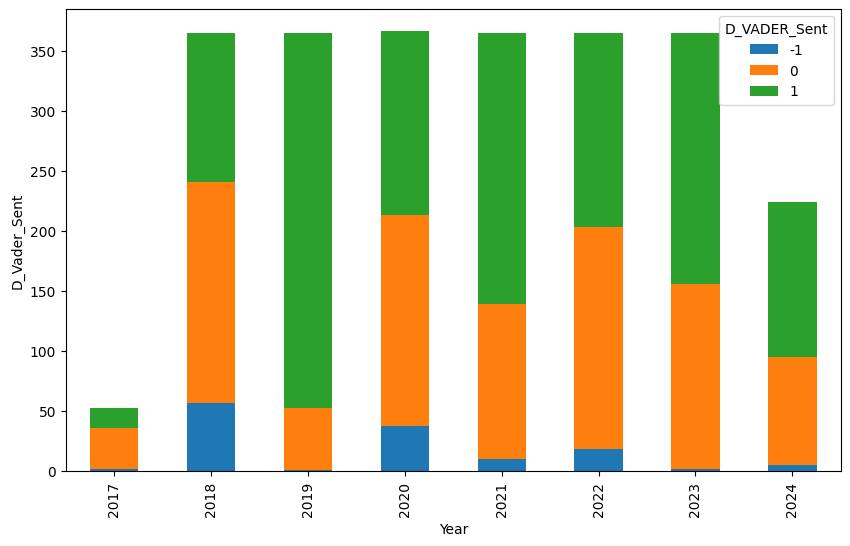

In [11]:
VSA = VaderSentimentAnalyser(processed_gn)
agg['D_VADER_Sent'] = agg['D_VADER_Score'].apply(VSA.determine_sentiment)
grouped = agg.groupby(['year', 'D_VADER_Sent']).size().unstack()
grouped
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent", stacked=True)

In [5]:
FSA = FinbertSentimentAnalyser(processed_gn)
processed_gn = FSA.analyse_sentiment("News Headline")

Device set to use cpu


KeyboardInterrupt: 

In [6]:
df = {"News Headline" : ["'Irrational exuberance' in ICOs but the tech is here to stay, Ethereum co-founder says - CNBC"]}
df = pd.DataFrame(df)
FSA = FinbertSentimentAnalyser(df)
df = FSA.analyse_sentiment("News Headline")

Device set to use cpu


In [7]:
df

,News Headline,D_FinBERT_Score,D_FinBERT_Sent
0,'Irrational exuberance' in ICOs but the tech i...,0.845581,0
